# Predict the vulnerability category of a smart contract from extracted source-code features.

For this lecture, we use SmartBugs-Curated, which is public on GitHub. It was created as a curated dataset of Solidity smart contracts annotated with tagged vulnerabilities, and SmartBugs’ own dataset documentation lists it as 143 curated vulnerable contracts. A related description also notes 10 DASP-derived vulnerability categories, which makes it a good fit for a multi-class supervised learning lecture rather than a simple safe-vs-vulnerable binary task.

https://github.com/smartbugs/smartbugs-curated

A second public dataset you can mention as an extension is SolidiFI-Benchmark, which is also on GitHub and contains bug-injected contracts spanning 7 bug types. It is useful for follow-up labs, but for a first lecture, SmartBugs-Curated is easier and cleaner because the classes are already organized by vulnerability family.

https://github.com/DependableSystemsLab/SolidiFI-benchmark

SmartBugs-Curated:

* multi-class classification of vulnerability type

* feature extraction from Solidity code

* Logistic Regression vs XGBoost comparison

Why it works well for class:

* public and easy to access from GitHub

* manageable size for a lecture demo: 143 contracts

* labels are meaningful vulnerability families rather than arbitrary IDs


### Build a DataFrame from the dataset

This reads Solidity files and uses the folder name as the class label. In SmartBugs-Curated, contracts are organized by vulnerability category, so this is a natural supervised-learning label construction.

In [4]:
import os
import pandas as pd

root_dir = "smartbugs-curated/dataset"

records = []

for vuln_type in os.listdir(root_dir):
    vuln_path = os.path.join(root_dir, vuln_type)
    if os.path.isdir(vuln_path):
        for file in os.listdir(vuln_path):
            if file.endswith(".sol"):
                file_path = os.path.join(vuln_path, file)
                with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                    code = f.read()
                records.append({
                    "file_name": file,
                    "label": vuln_type,
                    "code": code
                })

df = pd.DataFrame(records)
df.head(), df["label"].value_counts()

(                     file_name           label  \
 0  random_number_generator.sol  bad_randomness   
 1                  lottery.sol  bad_randomness   
 2            old_blockhash.sol  bad_randomness   
 3               etheraffle.sol  bad_randomness   
 4                blackjack.sol  bad_randomness   
 
                                                 code  
 0  /*\n * @source: https://github.com/SmartContra...  
 1  /*\n * @article: https://blog.positive.com/pre...  
 2  /*\n * @source: https://github.com/SmartContra...  
 3  /*\n * @article: https://blog.positive.com/pre...  
 4  /*\n * @article: https://blog.positive.com/pre...  ,
 label
 unchecked_low_level_calls    52
 reentrancy                   31
 access_control               18
 arithmetic                   15
 bad_randomness                8
 denial_of_service             6
 time_manipulation             5
 front_running                 4
 other                         3
 short_addresses               1
 Name: count, dtyp

### Feature extraction from smart contracts
Below is a feature extractor based on Solidity keywords and risky patterns. This is a handcrafted feature engineering step. It converts Solidity source code into numeric features that Logistic Regression and XGBoost can use.

In [7]:
import re

def extract_features(code):
    code_lower = code.lower()

    features = {
        "num_lines": len(code.splitlines()),
        "num_functions": len(re.findall(r"\bfunction\b", code_lower)),
        "num_require": len(re.findall(r"\brequire\s*\(", code_lower)),
        "num_assert": len(re.findall(r"\bassert\s*\(", code_lower)),
        "num_if": len(re.findall(r"\bif\b", code_lower)),
        "num_for": len(re.findall(r"\bfor\b", code_lower)),
        "num_while": len(re.findall(r"\bwhile\b", code_lower)),
        "num_mapping": len(re.findall(r"\bmapping\b", code_lower)),
        "num_modifier": len(re.findall(r"\bmodifier\b", code_lower)),
        "num_event": len(re.findall(r"\bevent\b", code_lower)),
        "num_payable": len(re.findall(r"\bpayable\b", code_lower)),
        "num_call": len(re.findall(r"\.call\b", code_lower)),
        "num_delegatecall": len(re.findall(r"\.delegatecall\b", code_lower)),
        "num_send": len(re.findall(r"\.send\b", code_lower)),
        "num_transfer": len(re.findall(r"\.transfer\b", code_lower)),
        "num_selfdestruct": len(re.findall(r"\bselfdestruct\b", code_lower)),
        "num_tx_origin": len(re.findall(r"\btx\.origin\b", code_lower)),
        "num_msg_sender": len(re.findall(r"\bmsg\.sender\b", code_lower)),
        "num_block_timestamp": len(re.findall(r"\bblock\.timestamp\b", code_lower)),
        "num_now": len(re.findall(r"\bnow\b", code_lower)),
        "num_arithmetic_ops": (
            code.count("+") + code.count("-") + code.count("*") + code.count("/")
        ),
    }
    return features

feature_rows = df["code"].apply(extract_features)
X = pd.DataFrame(feature_rows.tolist())
y = df["label"]

X.head()

,num_lines,num_functions,num_require,num_assert,num_if,num_for,num_while,num_mapping,num_modifier,num_event,...,num_call,num_delegatecall,num_send,num_transfer,num_selfdestruct,num_tx_origin,num_msg_sender,num_block_timestamp,num_now,num_arithmetic_ops
0,26,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,41
1,68,6,0,0,6,1,0,0,0,2,...,0,0,1,0,0,0,4,0,0,51
2,42,2,4,0,1,1,1,1,0,0,...,0,0,0,1,0,0,8,0,0,35
3,174,9,0,0,11,2,1,1,0,3,...,0,0,0,6,1,0,12,0,0,80
4,308,16,0,0,30,2,1,1,1,3,...,0,0,6,0,0,0,46,1,0,163


### Data cleaning
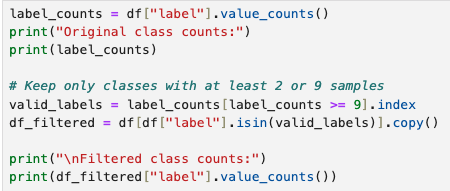

In [10]:
# Check for missing values
print(X.isnull().sum())

# Drop rows with missing values if any
valid_idx = X.dropna().index
X = X.loc[valid_idx]
y = y.loc[valid_idx]

print("Final dataset shape:", X.shape)

num_lines              0
num_functions          0
num_require            0
num_assert             0
num_if                 0
num_for                0
num_while              0
num_mapping            0
num_modifier           0
num_event              0
num_payable            0
num_call               0
num_delegatecall       0
num_send               0
num_transfer           0
num_selfdestruct       0
num_tx_origin          0
num_msg_sender         0
num_block_timestamp    0
num_now                0
num_arithmetic_ops     0
dtype: int64
Final dataset shape: (143, 21)


### Remove Very Small Classes
Bazı sınıflarda sadece 1 örnek varsa stratify hata verir.
Bu yüzden en az 2 örnek içeren sınıfları tutuyoruz.

Daha sağlam eğitim için bunu >= 8 de yapabilirsiniz.

In [13]:
label_counts = df["label"].value_counts()
print("Original class counts:")
print(label_counts)

# Keep only classes with at least 2 or 9 samples
valid_labels = label_counts[label_counts >= 9].index
df_filtered = df[df["label"].isin(valid_labels)].copy()

print("\nFiltered class counts:")
print(df_filtered["label"].value_counts())

Original class counts:
label
unchecked_low_level_calls    52
reentrancy                   31
access_control               18
arithmetic                   15
bad_randomness                8
denial_of_service             6
time_manipulation             5
front_running                 4
other                         3
short_addresses               1
Name: count, dtype: int64

Filtered class counts:
label
unchecked_low_level_calls    52
reentrancy                   31
access_control               18
arithmetic                   15
Name: count, dtype: int64


### Rebuild Features After Filtering
Filtreleme sonrası yeni feature matrix ve label set oluşturuyoruz.

In [16]:
feature_rows = df_filtered["code"].apply(extract_features)
X = pd.DataFrame(feature_rows.tolist())
y = df_filtered["label"]

print("Filtered feature matrix shape:", X.shape)
print("Filtered labels shape:", y.shape)

Filtered feature matrix shape: (116, 21)
Filtered labels shape: (116,)


### Encode labels
ML models need numeric labels, so this converts vulnerability names into class IDs.

In [19]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "->", cls)

Classes:
0 -> access_control
1 -> arithmetic
2 -> reentrancy
3 -> unchecked_low_level_calls


### Train-test split
We keep 80% for training and 20% for testing, while preserving class proportions. stratify=y_encoded her sınıfın oranını korur.

random_state for reproducibility.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (92, 21)
Test shape: (24, 21)


### Feature Scaling for Logistic Regression
Logistic Regression ölçeklenmiş özelliklerle daha iyi çalışır.
XGBoost için ölçekleme zorunlu değildir.

fit your model on the train set using fit() and perform prediction on the test set using predict(). 

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


### Logistic Regression Model
Bu model lineer bir sınıflandırıcıdır ve iyi bir baseline oluşturur.

In [31]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=2000,
    multi_class="multinomial"
)

log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)

print("Logistic Regression training completed.")

Logistic Regression training completed.


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### XGBoost Model
XGBoost doğrusal olmayan ilişkileri daha iyi öğrenebilir ve tabular veride genelde çok güçlü sonuç verir.

In [34]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    n_estimators=200,
    max_depth=4,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)

print("XGBoost training completed.")

XGBoost training completed.


### Basic Evaluation Function
Bu fonksiyon her model için temel evaluation metriklerini hesaplar.

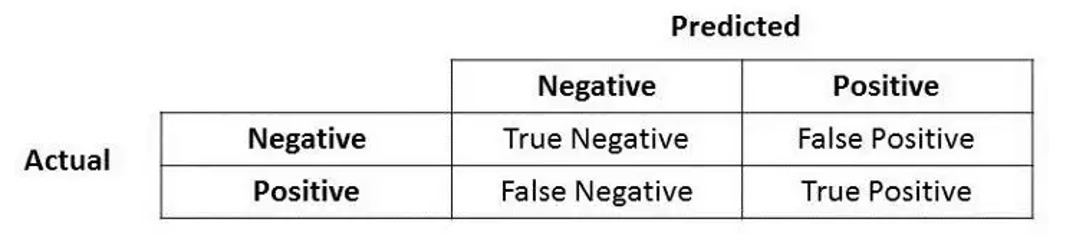

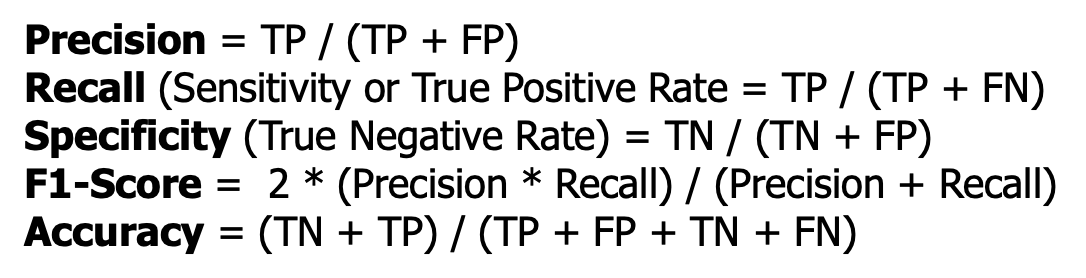

Precision: What do you notice for the denominator? The denominator is actually the Total Predicted Positive! You can see that Precision talks about how precise/accurate your model is out of those predicted positive, how many of them are actual positive. In our prediction case, when your Logistic Regression model predicted patients are going to suffer from diabetes, that patients have 82% of the time. Precision is a good measure to determine, when the costs of False Positive is high. For instance, email spam detection. In email spam detection, a false positive means that an email that is non-spam (actual negative) has been identified as spam (predicted spam). The email user might lose important emails if the precision is not high for the spam detection model.

Recall (Sensitivity): What do you notice for the denominator? The denominator is actually the Total Actual Positive! Recall shall be the model metric we use to select our best model when there is a high cost associated with False Negative. For instance, in fraud detection, if a fraudulent transaction (Actual Positive) is predicted as non-fraudulent (Predicted Negative), the consequence can be very bad for the bank. Similarly, in sick patient detection, if a sick patient (Actual Positive) goes through the test and predicted as not sick (Predicted Negative), the cost associated with False Negative will be extremely high if the sickness is contagious. In our case, if there are patients who have diabetes in the test set and your Logistic Regression model can identify it 61% of the time.

Specificity or True Negative Rate: It tells us what proportion of the negative class got correctly classified. For example, it would mean determining the proportion of healthy people who were correctly identified by the model.
TNR = TN / (TN + FP)

F1 score: It is needed when you want to seek a balance between Precision and Recall. It is the harmonic mean of Precision and Recall and gives a better measure of the incorrectly classified cases than the Accuracy Metric.

Accuracy: It observes correctly classified items both positive and negative.

So-what is the difference between F1 Score and Accuracy?
Accuracy is used when the True Positives and True negatives are more important while F1-score is used when the False Negatives and False Positives are crucial.
Accuracy can be used when the class distribution is similar while F1-score is a better metric when there are imbalanced classes.
In most real-life classification problems, imbalanced class distribution exists and thus F1-score is a better metric to evaluate our models on.


In [37]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    print(f"\n--- {model_name} ---")
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1-score :", round(f1, 4))

### Evaluate Logistic Regression and XGBoost
İki modeli accuracy, precision, recall ve F1-score ile karşılaştırıyoruz.

In [40]:
evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_xgb, "XGBoost")


--- Logistic Regression ---
Accuracy : 0.8333
Precision: 0.8023
Recall   : 0.8314
F1-score : 0.8109

--- XGBoost ---
Accuracy : 0.875
Precision: 0.8856
Recall   : 0.8523
F1-score : 0.8578


### Detailed Classification Report

In [44]:
from sklearn.metrics import classification_report

print("\nLogistic Regression Report:")
print(classification_report(y_test, y_pred_lr, target_names=label_encoder.classes_))

print("\nXGBoost Report:")
print(classification_report(y_test, y_pred_xgb, target_names=label_encoder.classes_))


Logistic Regression Report:
                           precision    recall  f1-score   support

           access_control       0.75      0.75      0.75         4
               arithmetic       0.75      1.00      0.86         3
               reentrancy       0.80      0.67      0.73         6
unchecked_low_level_calls       0.91      0.91      0.91        11

                 accuracy                           0.83        24
                macro avg       0.80      0.83      0.81        24
             weighted avg       0.84      0.83      0.83        24


XGBoost Report:
                           precision    recall  f1-score   support

           access_control       0.80      1.00      0.89         4
               arithmetic       1.00      0.67      0.80         3
               reentrancy       0.83      0.83      0.83         6
unchecked_low_level_calls       0.91      0.91      0.91        11

                 accuracy                           0.88        24
           

### Confusion Matrix for XGBoost
Bu görsel hangi sınıfların birbiriyle karıştırıldığını gösterir.

A confusion matrix is a technique for summarizing the performance of a classification algorithm.
The confusion matrix is in the form of the array object.

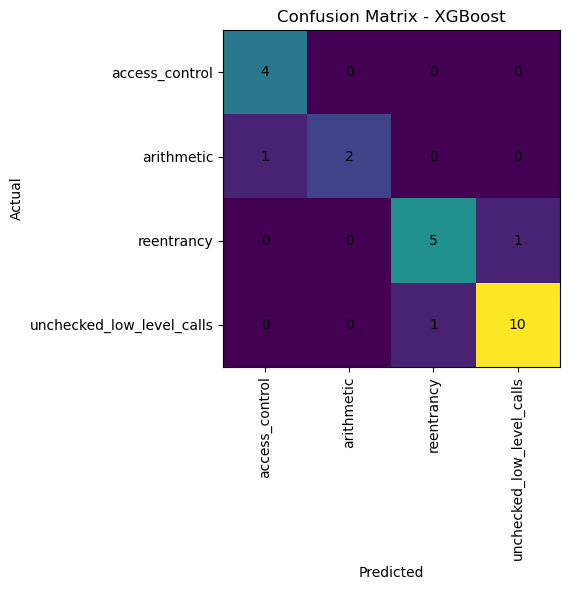

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=90)
plt.yticks(range(len(label_encoder.classes_)), label_encoder.classes_)
plt.tight_layout()
plt.show()

### ROC-AUC
Multi-class setting’de ROC-AUC değerini one-vs-rest yaklaşımıyla hesaplıyoruz.

ROC Curve:
Receiver Operating Characteristic(ROC) curve is a plot of the true positive rate against the false positive rate. The ROC curve is plotted with TPR on the y-axis and FPR is on the x-axis.
True Positive Rate (TPR) is a synonym for recall or sensitivity as we described previously.
False Positive Rate (FPR) is defined as:
FPR = FP / (FP + TN)

AUC: Area Under the ROC Curve
AUC stands for "Area under the ROC Curve." That is, AUC measures the entire two-dimensional area underneath the entire ROC curve (think integral calculus) from (0,0) to (1,1). In Machine Learning, performance measurement is an essential task. So when it comes to a classification problem, we can count on an AUC. It tells how much the model is capable of distinguishing between classes. Higher the AUC, the better the model is at predicting 0 classes as 0 and 1 classes as 1. By analogy, the Higher the AUC, the better the model is at distinguishing between patients with the disease and no disease.

In [51]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

y_test_bin = label_binarize(y_test, classes=range(len(label_encoder.classes_)))

roc_auc_lr = roc_auc_score(y_test_bin, y_prob_lr, multi_class="ovr")
roc_auc_xgb = roc_auc_score(y_test_bin, y_prob_xgb, multi_class="ovr")

print("ROC-AUC (Logistic Regression):", round(roc_auc_lr, 4))
print("ROC-AUC (XGBoost):", round(roc_auc_xgb, 4))

ROC-AUC (Logistic Regression): 0.9187
ROC-AUC (XGBoost): 0.9789


### Feature Importance for XGBoost
XGBoost hangi özellikleri en önemli bulduğunu gösterir.

In [55]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_df.head(10))

               feature  importance
19             num_now    0.343670
5              num_for    0.084799
11            num_call    0.083722
3           num_assert    0.067104
7          num_mapping    0.063331
14        num_transfer    0.057279
10         num_payable    0.048672
13            num_send    0.046762
1        num_functions    0.034953
20  num_arithmetic_ops    0.030415


### Plot Feature Importance
Bu grafik, modelin hangi smart contract özelliklerine daha çok dikkat ettiğini gösterir.

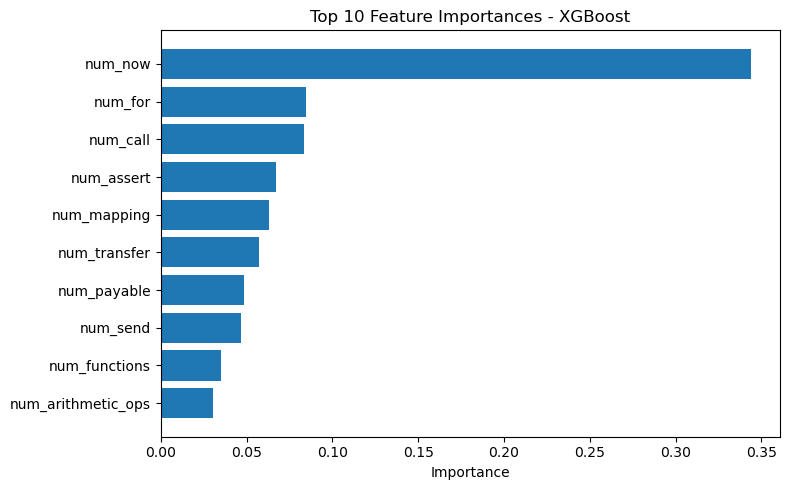

In [58]:
top_features = importance_df.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances - XGBoost")
plt.tight_layout()
plt.show()

### Comparison Table

In [61]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def get_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return [acc, precision, recall, f1]

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost"],
    "Accuracy": [get_metrics(y_test, y_pred_lr)[0], get_metrics(y_test, y_pred_xgb)[0]],
    "Precision": [get_metrics(y_test, y_pred_lr)[1], get_metrics(y_test, y_pred_xgb)[1]],
    "Recall": [get_metrics(y_test, y_pred_lr)[2], get_metrics(y_test, y_pred_xgb)[2]],
    "F1-score": [get_metrics(y_test, y_pred_lr)[3], get_metrics(y_test, y_pred_xgb)[3]],
})

comparison_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.833333,0.802273,0.831439,0.810877
1,XGBoost,0.875000,0.885606,0.852273,0.857828


CONCLUSION:
* Logistic Regression daha basit ve daha yorumlanabilir bir modeldir.
* XGBoost genellikle daha güçlüdür çünkü doğrusal olmayan ilişkileri öğrenebilir.
* Smart contract vulnerability detection gibi görevlerde evaluation sadece accuracy ile değil, precision / recall / F1 ile de yapılmalıdır.